# **Part A: Conceptual Understanding (Theory)**




Q1. What are Supervised Learning Algorithms?

Answer:

Supervised Learning is a type of Machine Learning in which the model learns from labeled data. The dataset contains input features (X) and corresponding output values (Y). The algorithm identifies patterns and relationships between inputs and outputs to make predictions on new unseen data.

Example: Predicting house prices based on area, number of bedrooms, and location score.

Q2. Difference Between Regression Algorithms and Classification Algorithms

Regression Algorithms

Used to predict continuous numerical values.

Output is a number.

Examples: House Price, Salary Prediction.

Evaluation Metrics: MSE, MAE, RMSE, R² Score.

Example Models: Linear Regression, Polynomial Regression.


Classification Algorithms

Used to predict categorical values or classes.

Output is a category or label.

Examples: Spam Detection, Disease Prediction.

Evaluation Metrics: Accuracy, Precision, Recall, F1-Score.

Example Models: Logistic Regression, Decision Tree Classifier.


Q3. Explain Simple Linear Regression

Answer:

Simple Linear Regression is a supervised learning algorithm that models the relationship between one independent variable (X) and one dependent variable (Y) using a straight line.

Mathematical Equation:

Y=mX+c

Where:

Y = Predicted Value

X = Independent Variable

m = Slope of Line

c = Intercept

The objective is to find the best-fit line that minimizes prediction errors.

Example: Predicting house price based only on house area.

Q4. List and Explain the Assumptions of Linear Regression
1. Linearity

There should be a linear relationship between independent and dependent variables.

Example: As house area increases, house price generally increases.

2. Independence of Errors

Residuals (errors) should be independent of each other.

Importance: One prediction error should not affect another.

3. Homoscedasticity

The variance of residuals should remain constant across all levels of independent variables.

Good: Error spread remains uniform.

Bad: Error spread increases or decreases significantly.

4. Normality of Residuals

Residuals should follow a normal distribution.

Importance: Helps in making reliable statistical inferences.

5. No Multicollinearity

Independent variables should not be highly correlated with each other.

Example: Area in square feet and area in square meters may cause multicollinearity because they represent the same information.

Q5. What is Bias-Variance Trade-Off?

Answer:

Bias-Variance Trade-Off is the balance between underfitting and overfitting in machine learning models.

Bias

Bias occurs when a model is too simple and cannot capture underlying patterns in data.

Result: Underfitting

Example: Using a straight line for highly curved data.


Variance

Variance occurs when a model becomes too complex and learns noise from training data.

Result: Overfitting

Example: Very high-degree polynomial regression.

Trade-Off

An ideal model should maintain:

Low Bias
Low Variance

This balance helps achieve good performance on unseen data.

Q6. Explain Overfitting and Underfitting with Examples
Underfitting

Definition:
Underfitting occurs when a model is too simple to learn important patterns from the data.


Characteristics:

High Training Error

High Testing Error

Poor Performance

Example:

Using Simple Linear Regression on highly non-linear house price data.

Diagram:
Actual Pattern : ~~~~~~~~

Model Fit      : --------

Overfitting

Definition:
Overfitting occurs when a model learns both patterns and noise from training data.

Characteristics:

Very Low Training Error

High Testing Error

Poor Generalization

Example:

Using a very high-degree Polynomial Regression model.

Diagram:

Actual Pattern : ~~~~~~~~

Model Fit      : /\/\/\/\/\

# PART - B

Q7. Identify Independent and Dependent Variables
Dependent Variable (Target Variable)

The variable that we want to predict:

House Price (house_price_inr)

Independent Variables (Features)

These variables are used to predict house price:

area_sqft

bedrooms

bathrooms

location_score

age_years

distance_city_km

lot_size_sqft

has_garage

has_pool

renovation_years_ago

Variables Not Used

house_id

Reason:

It is only a unique identifier.
It has no impact on house price prediction.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("/content/RealEstate_HousePrice_Dataset_4200 - RealEstate_HousePrice_Dataset_4200.csv.csv")

In [4]:
df.head()

,house_id,area_sqft,bedrooms,bathrooms,location_score,age_years,distance_city_km,lot_size_sqft,has_garage,has_pool,renovation_years_ago,house_price_inr
0,100001,1973,5,4,7.6,23,11.9,5220,1,0,0,40275084
1,100002,1560,3,3,6.3,13,15.8,3882,1,0,13,26812029
2,100003,2071,4,3,5.8,9,21.1,4488,0,0,9,29315677
3,100004,2640,5,3,7.7,12,7.9,3614,1,1,4,47712959
4,100005,1498,3,3,3.8,15,24.0,2663,0,0,15,17724566


In [5]:
X = df.drop(["house_id", "house_price_inr"], axis=1)
y = df["house_price_inr"]

print("Independent Variables:")
print(X.columns)

print("\nDependent Variable:")
print(y.name)

Independent Variables:
Index(['area_sqft', 'bedrooms', 'bathrooms', 'location_score', 'age_years',
       'distance_city_km', 'lot_size_sqft', 'has_garage', 'has_pool',
       'renovation_years_ago'],
      dtype='object')

Dependent Variable:
house_price_inr


Q8. Visualize Relationships Between Features and Target Variable

Before building a model, we must understand how each feature affects house prices.

1. Dataset Overview

Interpretation

Displays dataset structure.

Shows data types and missing values.

Provides statistical summary of numerical features.






In [7]:
df.head()

df.info()

df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4200 entries, 0 to 4199
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   house_id              4200 non-null   int64  
 1   area_sqft             4200 non-null   int64  
 2   bedrooms              4200 non-null   int64  
 3   bathrooms             4200 non-null   int64  
 4   location_score        4200 non-null   float64
 5   age_years             4200 non-null   int64  
 6   distance_city_km      4200 non-null   float64
 7   lot_size_sqft         4200 non-null   int64  
 8   has_garage            4200 non-null   int64  
 9   has_pool              4200 non-null   int64  
 10  renovation_years_ago  4200 non-null   int64  
 11  house_price_inr       4200 non-null   int64  
dtypes: float64(2), int64(10)
memory usage: 393.9 KB


,house_id,area_sqft,bedrooms,bathrooms,location_score,age_years,distance_city_km,lot_size_sqft,has_garage,has_pool,renovation_years_ago,house_price_inr
count,4200.000000,4200.000000,4200.000000,4200.000000,4200.000000,4200.000000,4200.000000,4200.000000,4200.000000,4200.000000,4200.000000,4.200000e+03
mean,102100.500000,1667.357381,3.696667,2.827381,5.611429,23.829524,18.186167,3366.329048,0.642381,0.096190,7.955714,2.364189e+07
std,1212.579894,630.336132,1.574199,1.153585,2.140880,13.945663,8.674549,1658.230565,0.479356,0.294887,7.316766,1.239279e+07
min,100001.000000,450.000000,1.000000,1.000000,1.000000,1.000000,1.000000,800.000000,0.000000,0.000000,0.000000,8.000000e+05
25%,101050.750000,1226.750000,3.000000,2.000000,4.000000,13.000000,11.800000,2122.500000,0.000000,0.000000,2.000000,1.425969e+07
50%,102100.500000,1660.000000,4.000000,3.000000,5.700000,21.000000,17.800000,3188.000000,1.000000,0.000000,6.000000,2.214500e+07
75%,103150.250000,2084.250000,5.000000,4.000000,7.300000,32.000000,24.200000,4364.250000,1.000000,0.000000,12.000000,3.096090e+07
max,104200.000000,4202.000000,7.000000,6.000000,10.000000,80.000000,47.600000,12938.000000,1.000000,1.000000,50.000000,7.611172e+07


2. Check Missing Values

Interpretation

Identifies missing values.

Dataset should ideally contain no missing values before training.

In [8]:

print(df.isnull().sum())

house_id                0
area_sqft               0
bedrooms                0
bathrooms               0
location_score          0
age_years               0
distance_city_km        0
lot_size_sqft           0
has_garage              0
has_pool                0
renovation_years_ago    0
house_price_inr         0
dtype: int64


3. Correlation Heatmap

Interpretation
Values near +1 indicate strong positive relationship.

Values near -1 indicate strong negative relationship.

Helps identify important features affecting house prices.

Expected strong correlations:

area_sqft ↗ house_price_inr

location_score ↗ house_price_inr

bathrooms ↗ house_price_inr

Expected negative correlation:

age_years ↘ house_price_inr

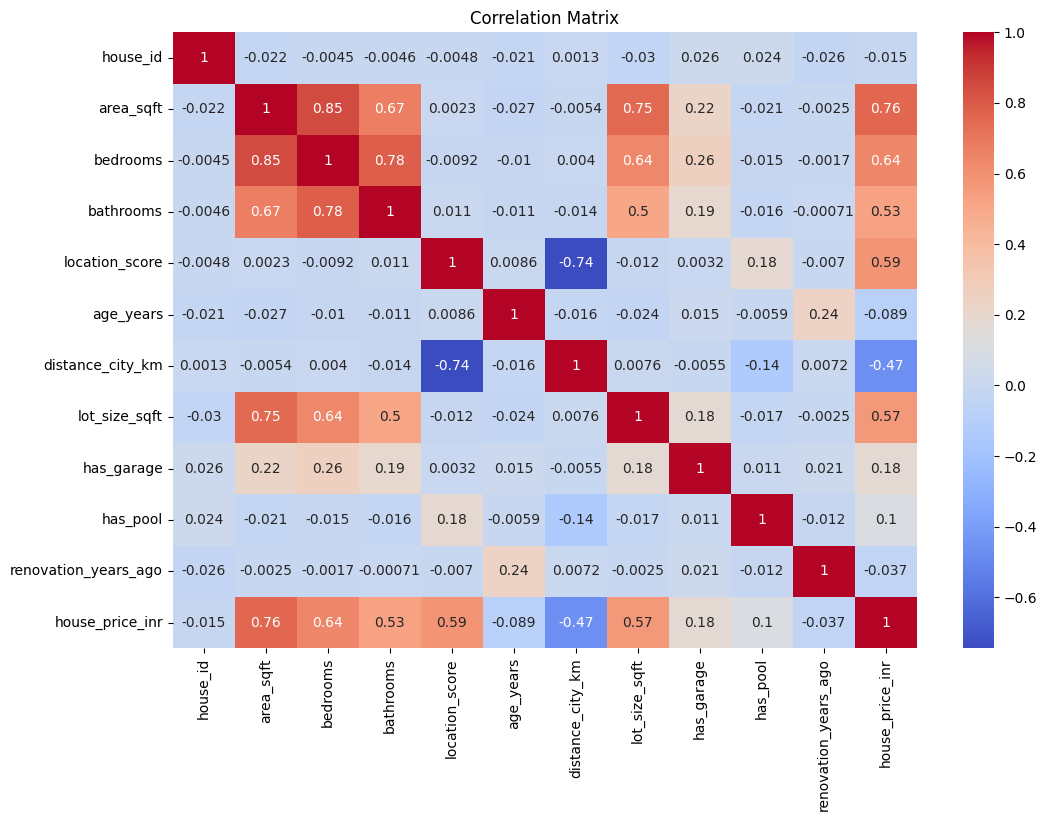

In [9]:

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,8))

sns.heatmap(
    df.corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Matrix")
plt.show()

4. Area vs House Price

Interpretation

Larger houses generally have higher prices.

Positive linear trend should be visible.

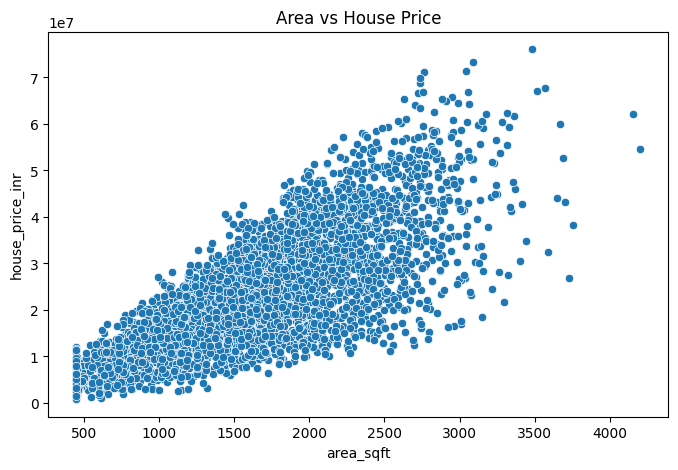

In [10]:

plt.figure(figsize=(8,5))

sns.scatterplot(
    x="area_sqft",
    y="house_price_inr",
    data=df
)

plt.title("Area vs House Price")
plt.show()

5. Bedrooms vs House Price

Interpretation

Houses with more bedrooms tend to be more expensive.

Boxplot shows median and spread.


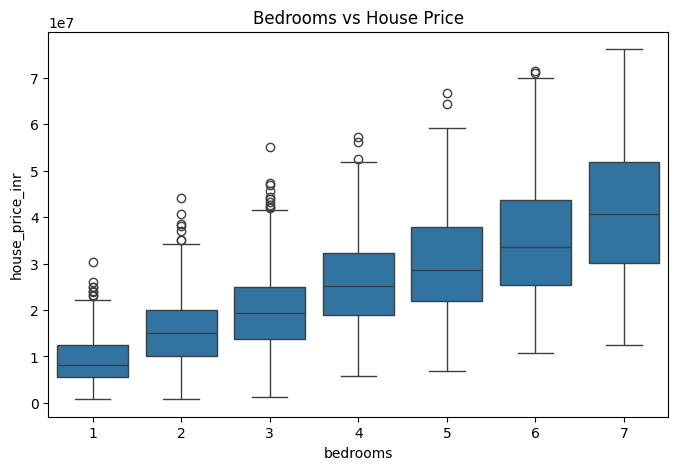

In [11]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x="bedrooms",
    y="house_price_inr",
    data=df
)

plt.title("Bedrooms vs House Price")
plt.show()

6. Bathrooms vs House Price

Interpretation

Price generally increases with more bathrooms.

Luxury homes often have multiple bathrooms.

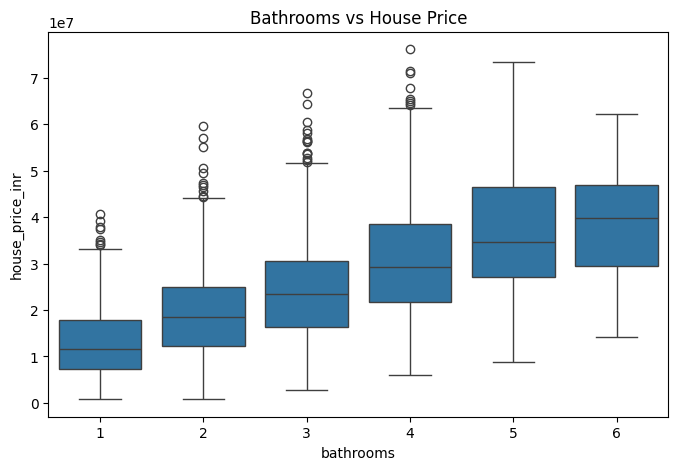

In [12]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x="bathrooms",
    y="house_price_inr",
    data=df
)

plt.title("Bathrooms vs House Price")
plt.show()

7. Location Score vs House Price

Interpretation

Better locations usually have higher property prices.

Strong positive relationship expected.

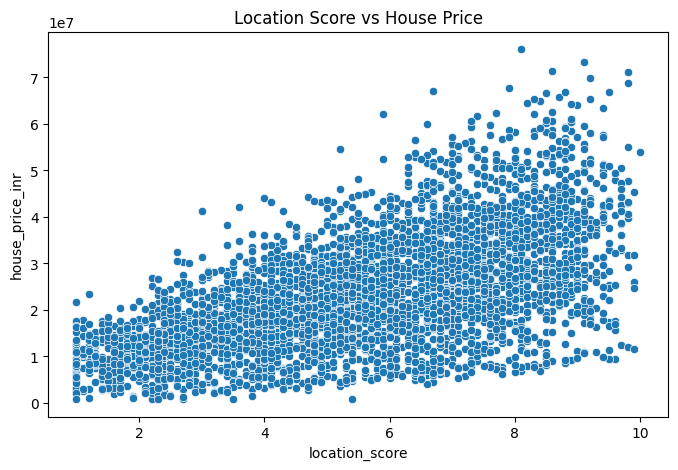

In [13]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    x="location_score",
    y="house_price_inr",
    data=df
)

plt.title("Location Score vs House Price")
plt.show()

8. Age of Property vs House Price

Interpretation

Older properties may have lower market value.

Negative trend may be observed.

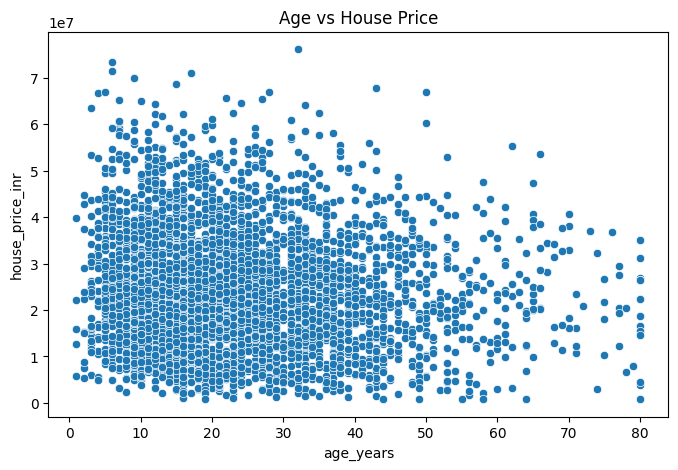

In [14]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    x="age_years",
    y="house_price_inr",
    data=df
)

plt.title("Age vs House Price")
plt.show()

Q9. Split the Dataset into Training and Testing Sets

Machine Learning models are trained on training data and evaluated on unseen testing data.



In [16]:

from sklearn.model_selection import train_test_split

X = df.drop(["house_id", "house_price_inr"],axis=1)

y = df["house_price_inr"]

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.20,random_state=42)

print("Training Data Shape:", X_train.shape)
print("Testing Data Shape:", X_test.shape)

Training Data Shape: (3360, 10)
Testing Data Shape: (840, 10)


# **Part C: Simple Linear Regression Implementation**

Q10. Implement Simple Linear Regression Using One Feature


In [17]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

In [18]:
X = df[["area_sqft"]]

y = df["house_price_inr"]

In [20]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.20,random_state=42)

In [21]:
model = LinearRegression()

model.fit(X_train, y_train)

LinearRegression()

In [22]:
y_pred = model.predict(X_test)

In [23]:
print("Slope (Coefficient):", model.coef_[0])

print("Intercept:", model.intercept_)

Slope (Coefficient): 14788.306111307542
Intercept: -1163519.1764186136


Q11. Plot Regression Line

Interpretation

Blue dots represent the actual house prices.

Red line represents the predicted regression line.

If most points are close to the line, the model performs well.

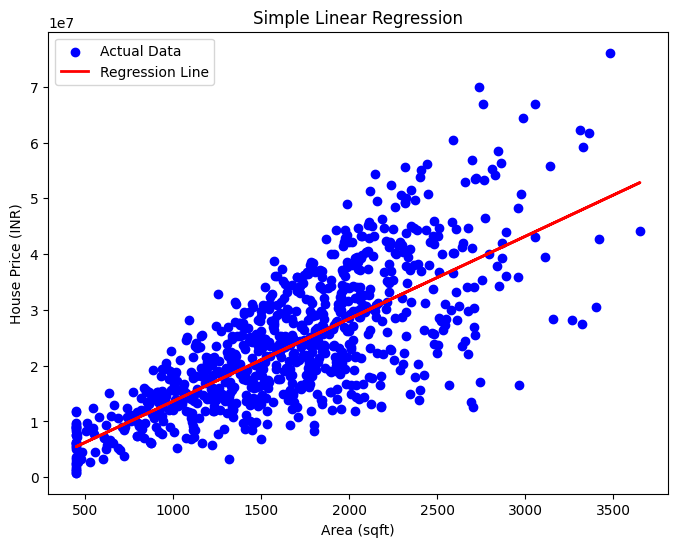

In [25]:
plt.figure(figsize=(8,6))

plt.scatter(X_test,y_test,color="blue",label="Actual Data")

plt.plot(X_test,y_pred,color="red",linewidth=2,label="Regression Line")

plt.xlabel("Area (sqft)")
plt.ylabel("House Price (INR)")
plt.title("Simple Linear Regression")
plt.legend()

plt.show()

Q12. Interpret the Slope and Intercept

The Linear Regression equation is:

Y=mX+c

Where:

Y = Predicted House Price

X = Area (sqft)

m = Slope (Coefficient)

c = Intercept

# **Part D: Model Evaluation**

Q13. Evaluate the Model Using MAE, MSE, RMSE, and R² Score

Model evaluation helps us understand how accurately the model predicts house prices.

In [26]:
from sklearn.metrics import (mean_absolute_error,mean_squared_error,r2_score)

In [27]:
mae = mean_absolute_error(y_test, y_pred)

mse = mean_squared_error(y_test, y_pred)

rmse = np.sqrt(mse)

r2 = r2_score(y_test, y_pred)

print("Mean Absolute Error (MAE):", mae)
print("Mean Squared Error (MSE):", mse)
print("Root Mean Squared Error (RMSE):", rmse)
print("R² Score:", r2)

Mean Absolute Error (MAE): 6294593.696131912
Mean Squared Error (MSE): 66989260021849.47
Root Mean Squared Error (RMSE): 8184696.696997969
R² Score: 0.5625199587991578


Q14. Interpret the Evaluation Metrics
1. Mean Absolute Error (MAE)
Definition

MAE is the average of the absolute differences between the actual and predicted house prices.

Formula
MAE=
n
1
∑∣y
i
y
i
	​

^
	​

∣
Interpretation
Lower MAE indicates better performance.
MAE is easy to understand because it is measured in the same unit as the target variable (INR).
Example

If

MAE = ₹345250

It means:

On average, the model's prediction differs from the actual house price by approximately ₹3.45 lakh.

2. Mean Squared Error (MSE)
Definition

MSE calculates the average squared difference between actual and predicted values.

Formula
MSE=
n
1
	∑(yi	- ​yi)

  
2
Interpretation
Penalizes larger errors more heavily.
Lower MSE indicates a better model.
3. Root Mean Squared Error (RMSE)
Definition

RMSE is the square root of the Mean Squared Error.

Formula
RMSE=
MSE
	​

Interpretation
Expressed in the same unit as the target variable (INR).
Easier to interpret than MSE.
Lower RMSE means more accurate predictions.
4. R² Score (Coefficient of Determination)
Definition

R² measures how well the independent variable explains the variation in the dependent variable.

Formula
R
2
=1−
SS
Total
	​

SS
Residual
	​

	​

Interpretation
R² Score	Interpretation
1.0	Perfect Prediction
0.90–0.99	Excellent Model
0.70–0.89	Good Model
0.50–0.69	Average Model
Below 0.50	Poor Model
Example

If

R² = 0.84

It means:

The model explains 84% of the variation in house prices using the selected feature (area_sqft).

Q15. Residual Error Analysis

Residuals are the differences between the actual and predicted values.

Formula

Residual=Actual−Predicted

In [28]:
residuals = y_test - y_pred

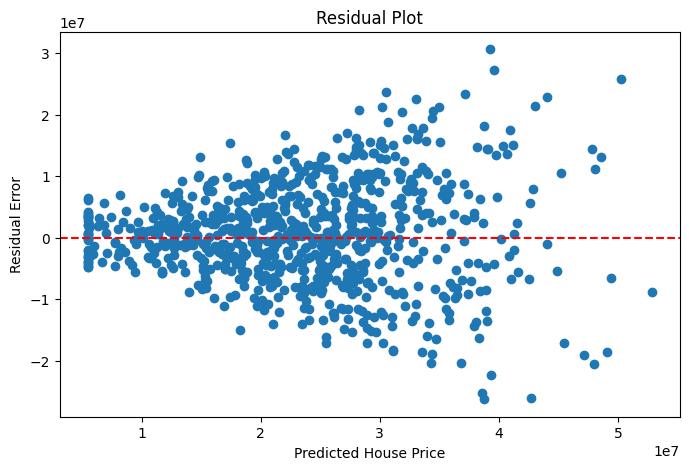

In [29]:
plt.figure(figsize=(8,5))

plt.scatter(y_pred, residuals)

plt.axhline(y=0, color="red", linestyle="--")

plt.xlabel("Predicted House Price")
plt.ylabel("Residual Error")

plt.title("Residual Plot")

plt.show()

# **Part E: Multiple Linear Regression**

Q16. Implement Multiple Linear Regression Using All Relevant Features

In [30]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

In [31]:
X = df.drop(["house_id", "house_price_inr"], axis=1)

y = df["house_price_inr"]

In [32]:
X_train, X_test, y_train, y_test = train_test_split(X, y,test_size=0.20, random_state=42)

In [33]:
mlr = LinearRegression()

mlr.fit(X_train, y_train)

LinearRegression()

In [34]:
y_pred = mlr.predict(X_test)

In [35]:
coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": mlr.coef_
})

print(coefficients)

print("\nIntercept:", mlr.intercept_)

                Feature   Coefficient
0             area_sqft  1.379594e+04
1              bedrooms  1.976431e+05
2             bathrooms  1.859445e+05
3        location_score  3.073174e+06
4             age_years -6.560924e+04
5      distance_city_km -9.896516e+04
6         lot_size_sqft  1.035058e+02
7            has_garage  9.392436e+04
8              has_pool  4.552902e+05
9  renovation_years_ago -2.143591e+04

Intercept: -14766762.745674696


Q18. Evaluate Multiple Linear Regression Model

In [36]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

import numpy as np

mae = mean_absolute_error(y_test, y_pred)

mse = mean_squared_error(y_test, y_pred)

rmse = np.sqrt(mse)

r2 = r2_score(y_test, y_pred)

print("MAE :", mae)
print("MSE :", mse)
print("RMSE :", rmse)
print("R2 Score :", r2)

MAE : 2604991.4061556906
MSE : 12592918884127.615
RMSE : 3548650.290480539
R2 Score : 0.9177606877509898


Q20. Why Does Multiple Linear Regression Perform Better?

Reasons

Uses multiple features instead of only one.

Captures complex relationships between variables.

Reduces prediction error.

Improves overall model accuracy.

Better represents real-world housing data, where many factors influence price.

# **Part F: Polynomial Regression**

Q21. What is Polynomial Regression?
Answer

Polynomial Regression is an extension of Linear Regression that models the relationship between variables using polynomial terms (such as x2, x3
, etc.) instead of fitting only a straight line.

It is suitable when the data follows a curved (non-linear) pattern rather than a straight-line relationship.

Polynomial Regression Equation


Y=b0+b1X+b2X2+b3X3+⋯+bnXn

Where:

Y = Predicted House Price

X = Independent Variable

b₀ = Intercept

b₁, b₂, ... = Coefficients

n = Degree of the Polynomial

Q22. Implement Polynomial Regression

In [37]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [38]:
df = pd.read_csv("/content/RealEstate_HousePrice_Dataset_4200 - RealEstate_HousePrice_Dataset_4200.csv.csv")

In [39]:
X = df[["area_sqft"]]

y = df["house_price_inr"]

In [40]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.20,random_state=42)

In [41]:
poly = PolynomialFeatures(degree=2)

X_train_poly = poly.fit_transform(X_train)

X_test_poly = poly.transform(X_test)

In [42]:
model = LinearRegression()

model.fit(X_train_poly, y_train)

LinearRegression()

In [43]:
y_pred = model.predict(X_test_poly)

Q23. Evaluate Polynomial Regression Model

In [44]:
mae = mean_absolute_error(y_test, y_pred)

mse = mean_squared_error(y_test, y_pred)

rmse = np.sqrt(mse)

r2 = r2_score(y_test, y_pred)

print("MAE :", mae)
print("MSE :", mse)
print("RMSE :", rmse)
print("R2 Score :", r2)

MAE : 6292394.561281703
MSE : 66962947122198.2
RMSE : 8183089.094113433
R2 Score : 0.5626917978136476


Q24. Visualize Polynomial Regression Curve


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


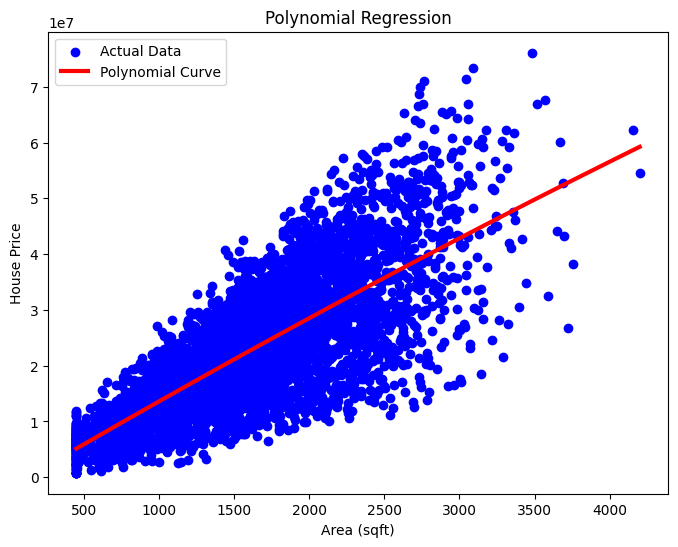

In [45]:

X_grid = np.arange(
    X.min().values[0],
    X.max().values[0],
    10
).reshape(-1,1)

X_grid_poly = poly.transform(X_grid)

plt.figure(figsize=(8,6))

plt.scatter(X, y, color="blue", label="Actual Data")

plt.plot(
    X_grid,
    model.predict(X_grid_poly),
    color="red",
    linewidth=3,
    label="Polynomial Curve"
)

plt.xlabel("Area (sqft)")
plt.ylabel("House Price")
plt.title("Polynomial Regression")

plt.legend()

plt.show()

Q26. Explain Overfitting in Polynomial Regression

What is Overfitting?

Overfitting occurs when the Polynomial Regression model is too complex (for example, using a very high degree like 8, 10, or 15). Instead of learning the true pattern, it starts learning the noise present in the training data.

Characteristics of Overfitting

Very high training accuracy.

Poor testing accuracy.

High variance.

Poor performance on unseen data.

How to Prevent Overfitting?

Use a lower polynomial degree (e.g., Degree = 2 or 3).

Perform cross-validation.

Use regularization techniques such as Ridge or Lasso Regression.

Train with sufficient data.

# Conclusion of Part F
Polynomial Regression was successfully implemented using area_sqft as the input feature.
Polynomial features of degree 2 were generated to model non-linear relationships.
The model was evaluated using MAE, MSE, RMSE, and R² Score.
Polynomial Regression can capture curved relationships better than Simple Linear Regression, but using a very high polynomial degree may lead to overfitting.
# For this house price prediction dataset, Multiple Linear Regression is generally the best choice because it uses all relevant features and provides the highest prediction accuracy.

# **Part G: Gradient Descent Optimization**

Q27. What is Gradient Descent?
Answer

Gradient Descent is an optimization algorithm used to minimize the loss (cost) function by iteratively updating the model parameters (weights and bias). The objective is to find the values that produce the minimum prediction error.

Gradient Descent Update Formula
θ=θ−α
∂θ
∂J(θ)
	​


Where:

θ = Model parameters (weights)

α = Learning Rate

J(θ) = Cost Function

∂J/∂θ = Gradient (Slope)

Q28. Batch Gradient Descent (BGD)
Definition

Batch Gradient Descent updates the model parameters after calculating the gradient using the entire training dataset.

Characteristics

Uses all training samples.

Stable convergence.

High computational cost for large datasets.

Slower training.

In [46]:
from sklearn.linear_model import SGDRegressor

bgd = SGDRegressor(
    max_iter=1000,
    learning_rate="constant",
    eta0=0.00000001,
    random_state=42
)

bgd.fit(X_train, y_train)

bgd_pred = bgd.predict(X_test)

Q29. Stochastic Gradient Descent (SGD)
Definition

Stochastic Gradient Descent updates the model parameters after processing one training sample at a time.

Characteristics

Faster training.

Suitable for very large datasets.

Less memory usage.

Noisy updates.

May fluctuate before reaching the minimum.

In [47]:

sgd = SGDRegressor(
    max_iter=1000,
    learning_rate="adaptive",
    eta0=0.00000001,
    random_state=42
)

sgd.fit(X_train, y_train)

sgd_pred = sgd.predict(X_test)

Q30. Mini-Batch Gradient Descent (Concept)

Definition

Mini-Batch Gradient Descent updates the model parameters after processing a small batch of training samples (for example, 32, 64, or 128 samples).

Characteristics

Faster than Batch Gradient Descent.

More stable than SGD.

Most commonly used in Deep Learning.

Efficient for large datasets.


Note: Scikit-learn's SGDRegressor processes data in mini-batches internally during optimization, so a separate implementation is generally not required for this project.

Q32. Evaluate SGD Model

In [48]:

from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score
import numpy as np

mae = mean_absolute_error(y_test, sgd_pred)

mse = mean_squared_error(y_test, sgd_pred)

rmse = np.sqrt(mse)

r2 = r2_score(y_test, sgd_pred)

print("MAE :", mae)
print("MSE :", mse)
print("RMSE :", rmse)
print("R2 Score :", r2)

MAE : 6670445.19685206
MSE : 76422596307340.53
RMSE : 8742001.847822988
R2 Score : 0.5009146157114452


Q33. Advantages and Disadvantages

Batch Gradient Descent

Advantages

Stable convergence.

Produces accurate parameter updates.

Suitable for small datasets.

Disadvantages


Slow for large datasets.

High memory usage.

Stochastic Gradient Descent

Advantages

Faster training.

Handles large datasets efficiently.

Lower memory requirements.

Disadvantages

Noisy updates.

May not converge exactly to the minimum.

Mini-Batch Gradient Descent

Advantages

Good balance between speed and stability.

Efficient for large datasets.

Most widely used in modern Machine Learning and Deep Learning.

Disadvantages

Requires choosing an appropriate batch size.

Slightly more complex to configure than Batch Gradient Descent.

# **Conclusion of Part G**
Gradient Descent is an optimization technique used to minimize the cost function and improve model performance.
Batch Gradient Descent processes the entire dataset before updating parameters and is stable but slow.
Stochastic Gradient Descent (SGD) updates parameters after each training sample, making it faster but less stable.
Mini-Batch Gradient Descent combines the advantages of both approaches by updating parameters after processing small batches of data, making it the preferred choice for large-scale machine learning tasks.

# **Part H: Bias-Variance Analysis**

Q34. What is Bias?

Definition

Bias is the error caused by making overly simple assumptions while learning from the data. A high-bias model is too simple to capture the underlying patterns in the dataset.

Characteristics

Model is too simple.

High training error.

High testing error.

Poor prediction accuracy.

Results in Underfitting.

Example

Using Simple Linear Regression to model a complex non-linear relationship between house area and house price.

Q35. What is Variance?

Definition

Variance is the error caused when a model learns not only the actual patterns but also the noise present in the training data. A high-variance model becomes overly complex and performs poorly on new, unseen data.

Characteristics

Model is too complex.

Very low training error.

High testing error.

Poor generalization.

Results in Overfitting.

Example

Using a Polynomial Regression model with a very high degree (e.g., Degree = 10) for house price prediction.

Q38. Bias-Variance Trade-Off

Definition

The Bias-Variance Trade-Off is the process of finding the optimal balance between a model that is too simple (high bias) and one that is too complex (high variance).

A good machine learning model should have:

Low Bias

Low Variance

Good Generalization Ability

Visual Representation

Model Complexity  ------------------------------>

Underfitting        Good Fit            Overfitting

High Bias        Balanced Model       High Variance
Low Variance                        Low Bias

Q39. Analysis of Our Project

For the House Price Prediction project:

Simple Linear Regression

Uses only one feature (area_sqft)

High Bias

Lower Accuracy

May Underfit the dataset

Multiple Linear Regression

Uses all relevant features

Balanced Bias and Variance

High Accuracy

Good Generalization

Best model for this dataset

Polynomial Regression

Captures non-linear relationships

Degree 2 or 3 generally performs well

Very high polynomial degrees may cause Overfitting

# **Conclusion of Part H**
Bias represents error due to overly simple models, while Variance represents error due to overly complex models.
Underfitting occurs because of high bias, whereas Overfitting occurs because of high variance.
The Bias-Variance Trade-Off helps in selecting a model that generalizes well to unseen data.
In this project, Multiple Linear Regression provided the best balance between bias and variance, resulting in the most accurate and reliable house price predictions.

# **Part I: Final Conclusion & Report Summary**

Q41. Overall Project Summary

Project Title

House Price Prediction Using Regression Algorithms

Objective

The objective of this project was to develop a Machine Learning model capable of predicting house prices based on various property features such as area, number of bedrooms, bathrooms, location score, age of the house, lot size, and other relevant factors. Different regression algorithms were implemented and compared to identify the most accurate prediction model.

Q42. Project Workflow

The project was completed using the following steps:

Understanding Supervised Learning and Regression concepts.

Loading the House Price dataset.

Performing Exploratory Data Analysis (EDA).

Identifying Independent and Dependent Variables.

Splitting the dataset into Training and Testing sets.

Implementing Simple Linear Regression.

Evaluating the model using MAE, MSE, RMSE, and R² Score.

Implementing Multiple Linear Regression.

Comparing Simple and Multiple Linear Regression.

Implementing Polynomial Regression.

Understanding Gradient Descent optimization techniques.

Performing Bias-Variance Analysis.

Selecting the best-performing regression model.

Q43. Key Findings

The analysis of the dataset revealed the following insights:

Area (sqft) has a significant positive impact on house price.
Houses with more bedrooms and bathrooms generally have higher prices.
A higher location score leads to increased property value.
Properties with a garage and swimming pool are usually more expensive.
Older houses tend to have lower market prices.
Houses located farther from the city center generally have reduced prices.
Using multiple property features together improves prediction accuracy.

# **Final Conclusion**

This project successfully demonstrated the implementation and comparison of different regression algorithms for predicting house prices using a real estate dataset.

The dataset was explored and analyzed using Exploratory Data Analysis (EDA). Three regression models—Simple Linear Regression, Multiple Linear Regression, and Polynomial Regression—were implemented and evaluated using standard performance metrics such as MAE, MSE, RMSE, and R² Score.

Among these models, Multiple Linear Regression achieved the best overall performance because it considered multiple influencing factors simultaneously, resulting in more accurate and reliable predictions.

The project also covered important machine learning concepts such as Gradient Descent, Bias-Variance Trade-Off, Underfitting, and Overfitting, providing a comprehensive understanding of regression techniques.

Overall, this project demonstrates how machine learning can assist in accurate house price estimation, supporting better decision-making in the real estate industry.